In [1]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
main_color = 'steelblue'
dark_color = 'navy'
accent_color = 'orange'

In [ ]:
path_df_cleaned = 'Data/meteo_pivoted_cleaned.parquet'

df_cleaned = pd.read_parquet(path_df_cleaned)
df_cleaned.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'day', 'hour', 'day_of_week', 'month', 'season',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated', 'wind_sector'],
    

## Pollutants change through year, seasons, days of the week

In [21]:
pollutants = ['NOx', 'PM2.5','CO2', 'PN[5-100nm]', 'SO2','eBC2.5']

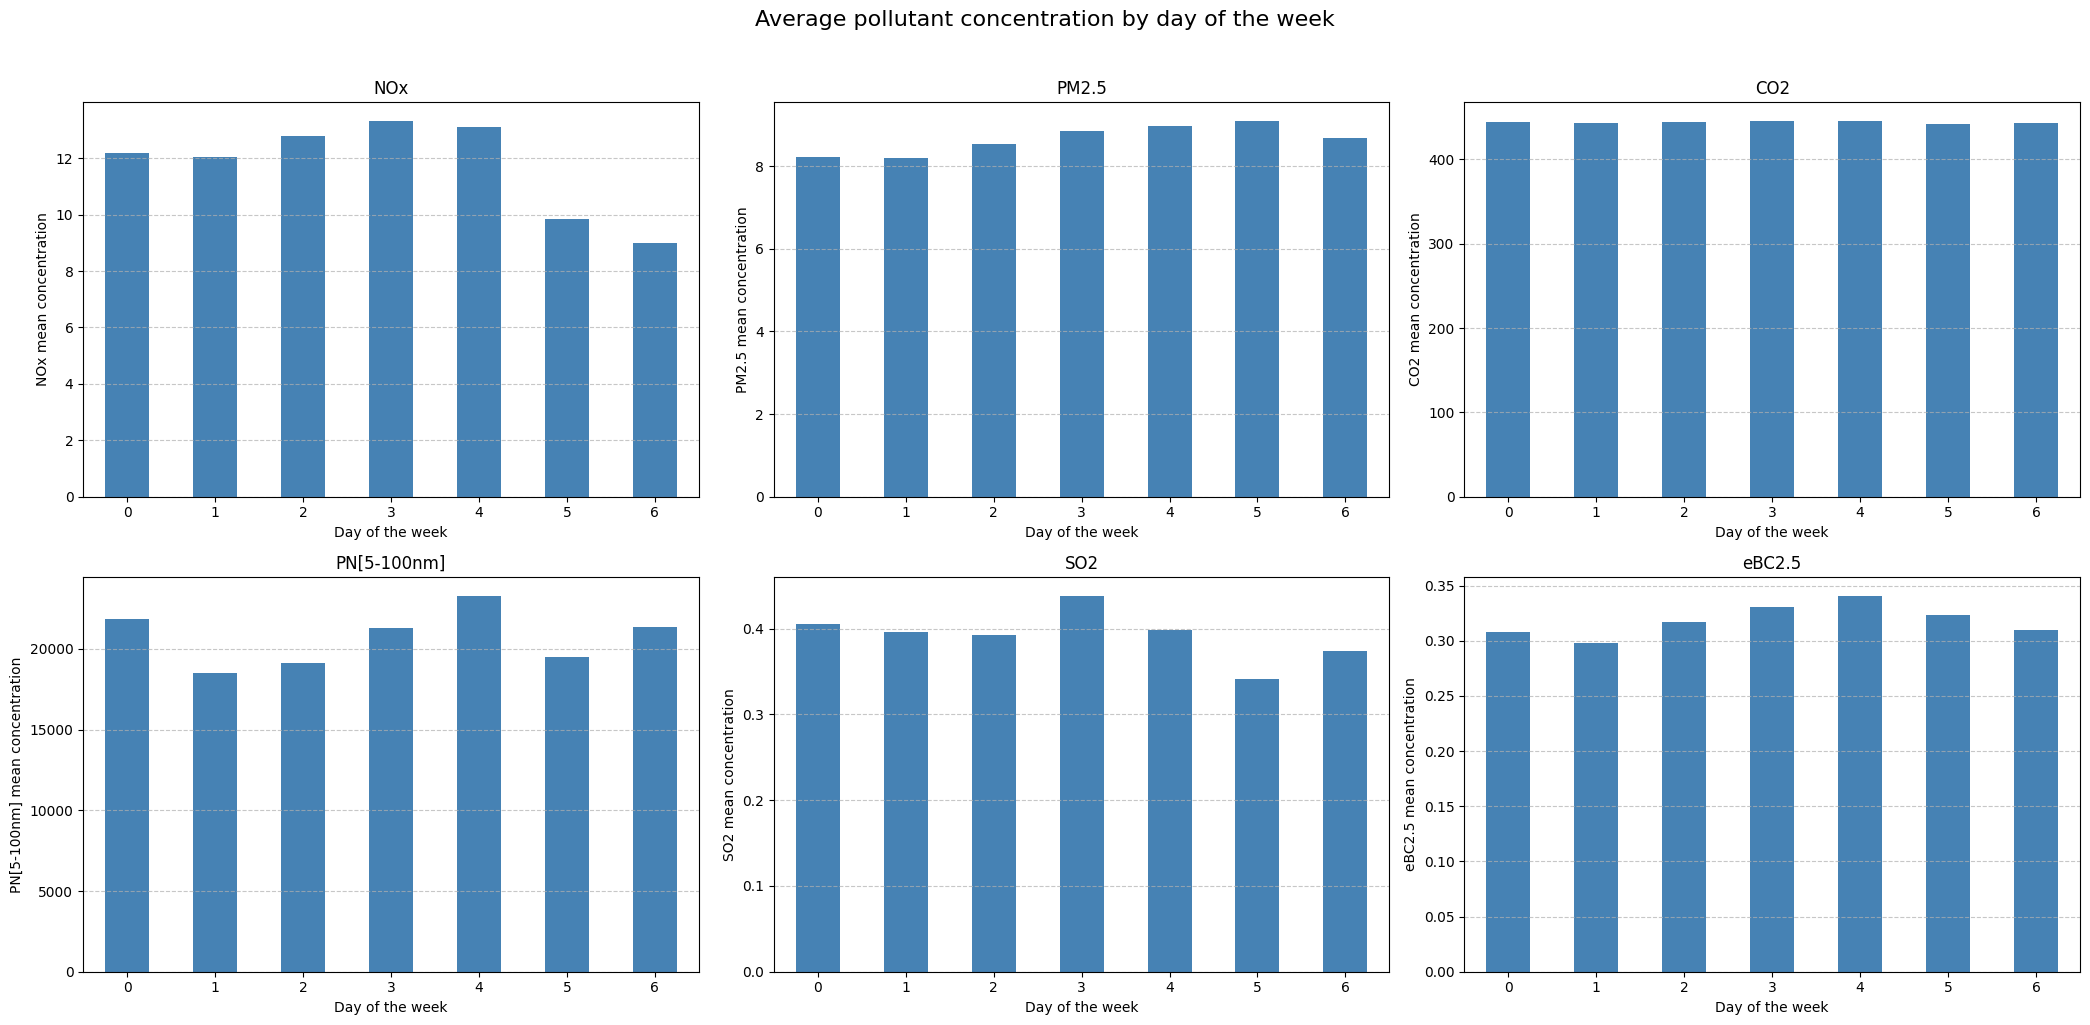

In [29]:
n_cols = 3
n_rows = (len(pollutants) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    mean_by_day = df_cleaned.groupby(df_cleaned['day_of_week'])[col].mean()
    mean_by_day.plot(kind='bar', color=main_color, ax=axes[i])
    
    axes[i].set_xlabel('Day of the week')
    axes[i].set_ylabel(f'{col} mean concentration')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_title(col)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')


plt.suptitle('Average pollutant concentration by day of the week', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


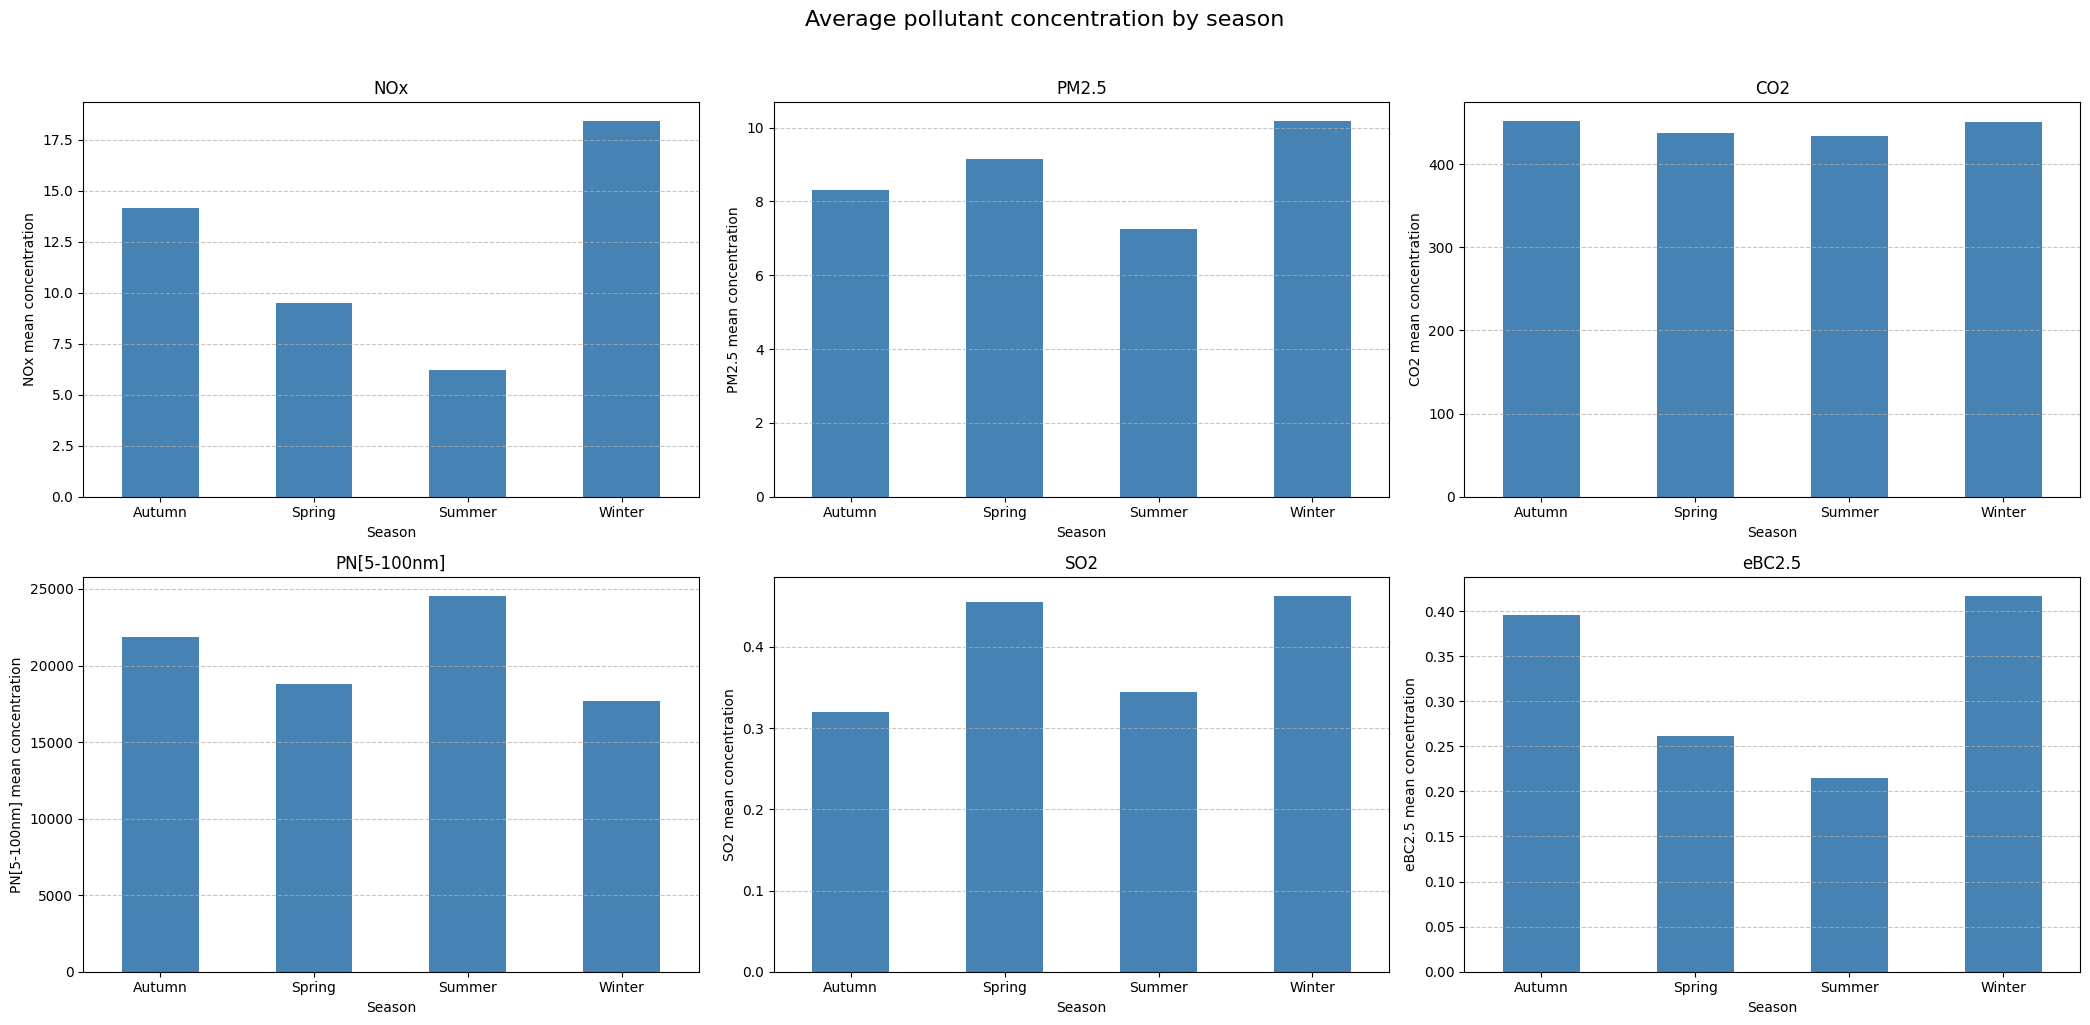

In [32]:
n_cols = 3
n_rows = (len(pollutants) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    mean_by_season = df_cleaned.groupby(df_cleaned['season'])[col].mean()
    mean_by_season.plot(kind='bar', color=main_color, ax=axes[i])
    
    axes[i].set_xlabel('Season')
    axes[i].set_ylabel(f'{col} mean concentration')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_title(col)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')


plt.suptitle('Average pollutant concentration by season', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [28]:
df_cleaned['day_of_year'] = df_cleaned.index.day_of_year

In [35]:
df_cleaned.to_parquet(path_df_cleaned)

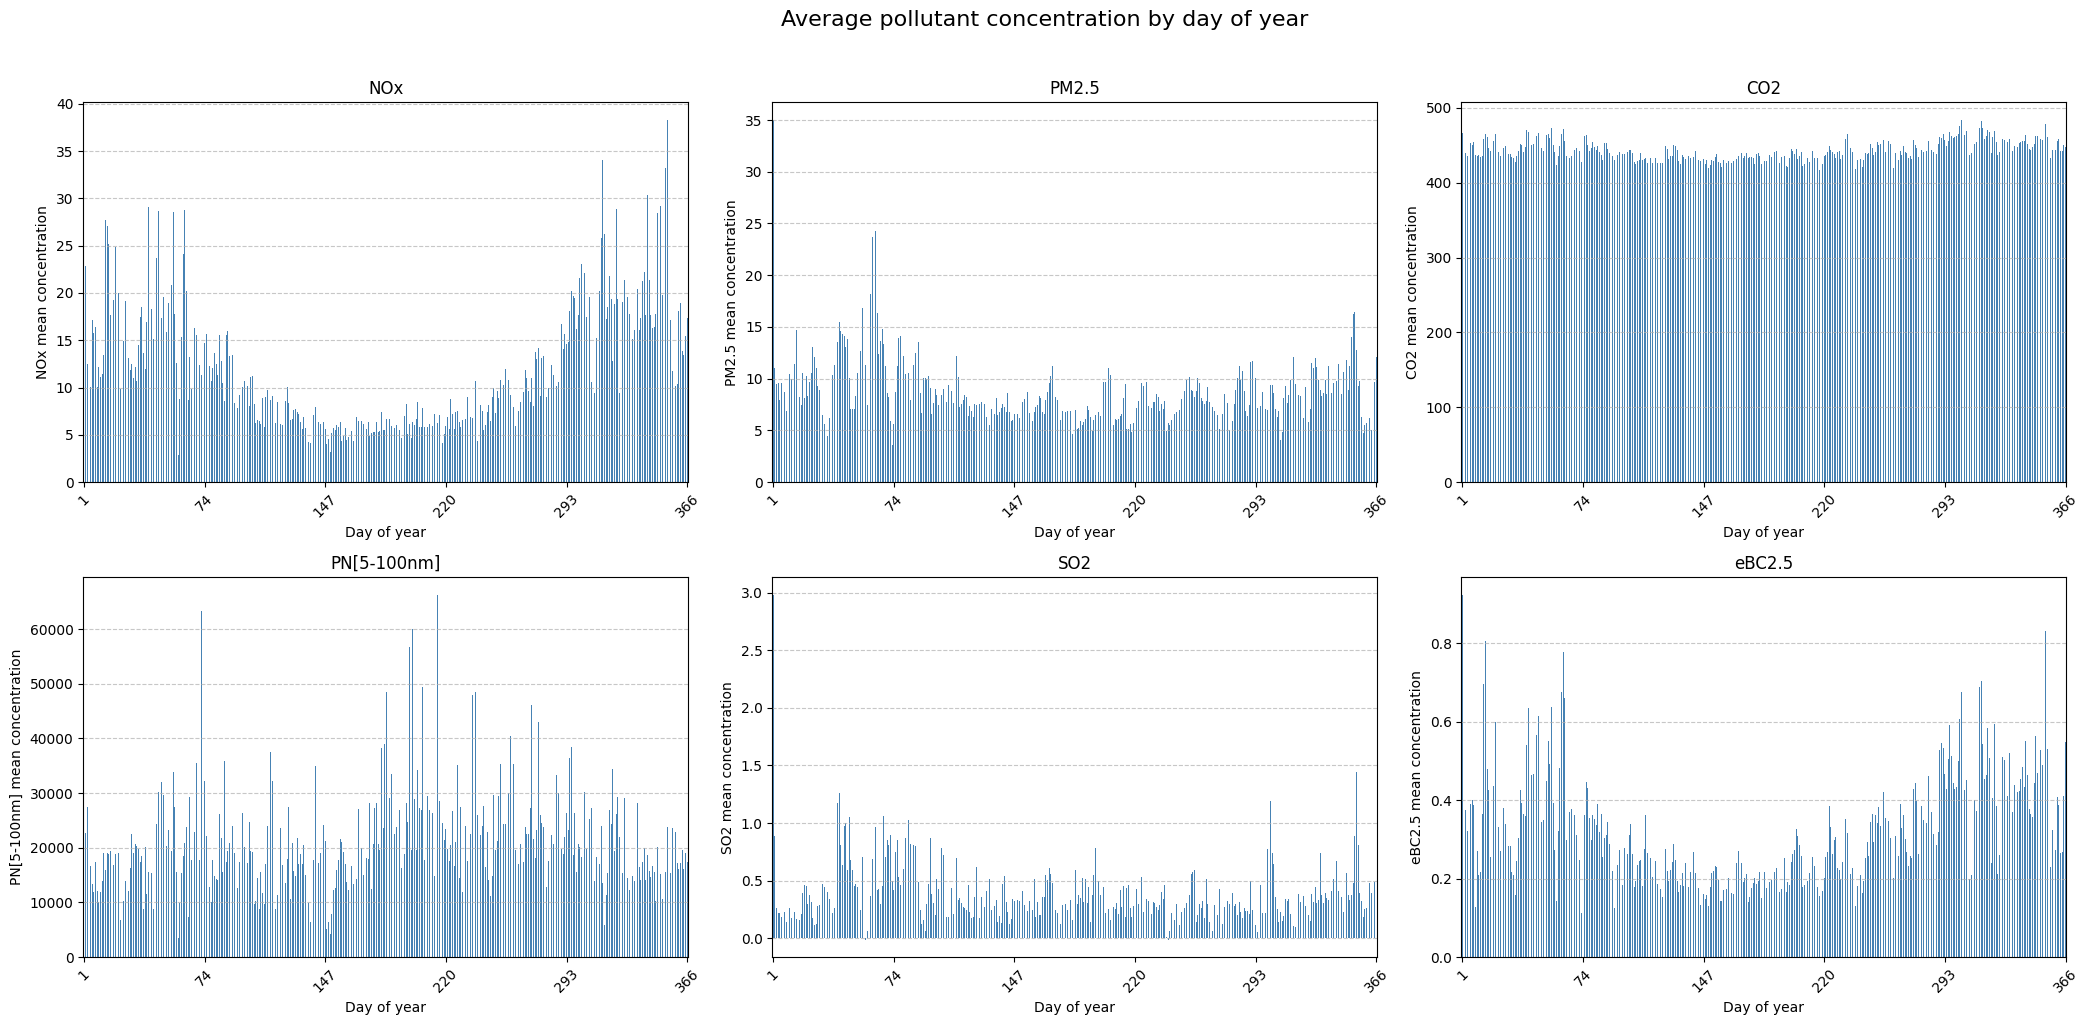

In [34]:
n_cols = 3
n_rows = (len(pollutants) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    mean_by_day_of_year = df_cleaned.groupby(df_cleaned['day_of_year'])[col].mean()
    mean_by_day_of_year.plot(kind='bar', color=main_color, ax=axes[i])

    tick_positions = range(0, len(mean_by_day_of_year), 73)
    tick_labels = [mean_by_day_of_year.index[i] for i in tick_positions]
    
    axes[i].set_xlabel('Day of year')
    axes[i].set_ylabel(f'{col} mean concentration')
    axes[i].set_xticks(tick_positions)
    axes[i].set_xticklabels(tick_labels, rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_title(col)
    

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')


plt.suptitle('Average pollutant concentration by day of year', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [42]:
pollutants

['NOx', 'PM2.5', 'CO2', 'PN[5-100nm]', 'SO2', 'eBC2.5']

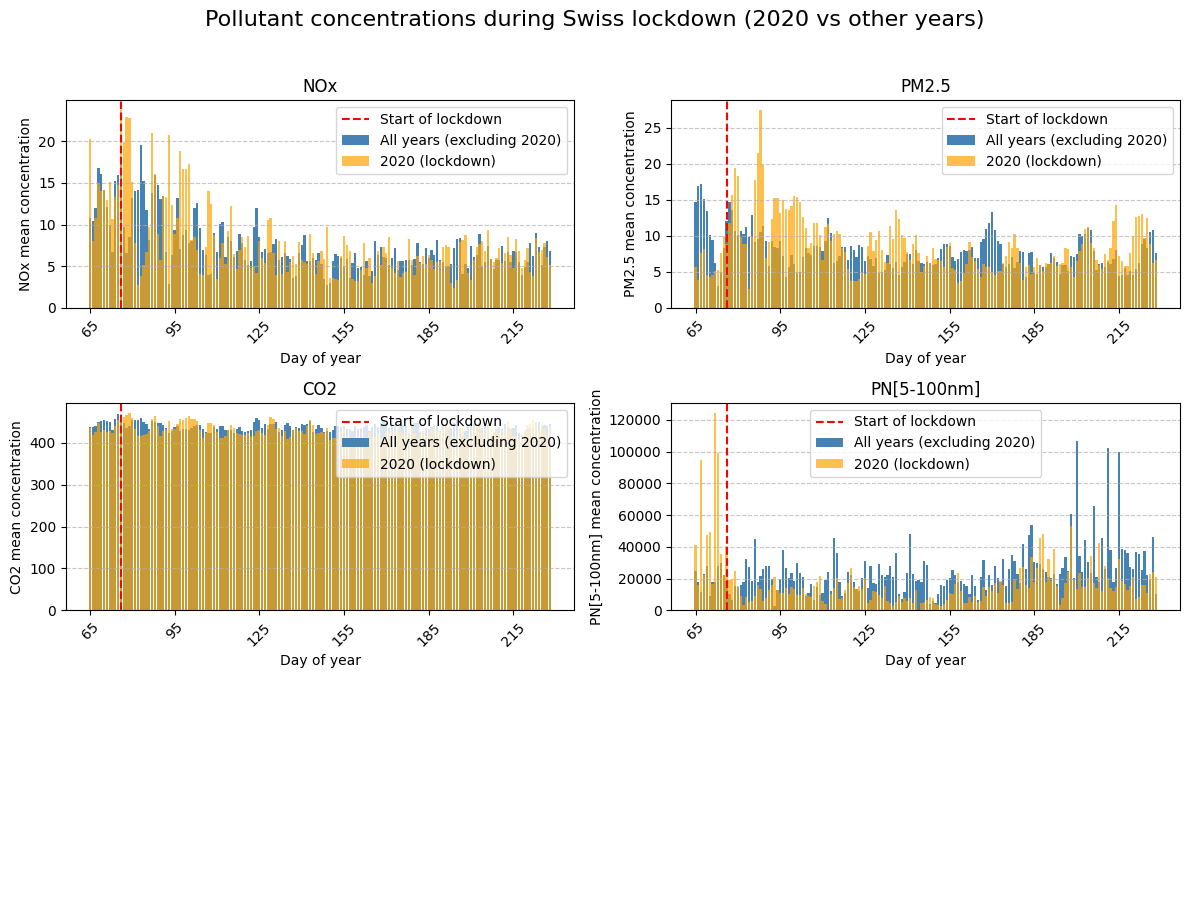

In [54]:
start_day = 65    # March 5
end_day = 228     # August 15

# Create filter masks
non_2020 = df_cleaned[df_cleaned['year'] != 2020]
just_2020 = df_cleaned[df_cleaned['year'] == 2020]

# remove SO2 and eBC2.5 from this analysis, as they are not (fully) available in the dataset for that period
pollutants_to_analyze = ['NOx', 'PM2.5', 'CO2', 'PN[5-100nm]']


n_cols = 2
n_rows = (len(pollutants) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(pollutants_to_analyze):
    # Mean for each day_of_year excluding 2020
    mean_all_years = (
        non_2020.groupby('day_of_year')[col]
        .mean()
        .loc[start_day:end_day]
    )

    # 2020 values per day_of_year
    values_2020 = (
        just_2020.groupby('day_of_year')[col]
        .mean()
        .loc[start_day:end_day]
    )

    # Ensure both have the same index (in case one has missing days)
    common_days = mean_all_years.index.intersection(values_2020.index)

    axes[i].bar(common_days, mean_all_years.loc[common_days], 
                color=main_color, label='All years (excluding 2020)')

    axes[i].bar(common_days, values_2020.loc[common_days], 
                color=accent_color, alpha=0.7, label='2020 (lockdown)')
    axes[i].axvline(x=76, color='red', linestyle='--', linewidth=1.5, label='Start of lockdown')


    axes[i].set_xlabel('Day of year')
    axes[i].set_ylabel(f'{col} mean concentration')
    axes[i].set_title(col)

    # Set ticks
    tick_positions = range(start_day, end_day + 1, 30)
    axes[i].set_xticks(tick_positions)
    axes[i].set_xticklabels(tick_positions, rotation=45)

    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].legend()

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Pollutant concentrations during Swiss lockdown (2020 vs other years)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
